In [8]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# 2. Load dataset
df = pd.read_csv("/content/heart.csv")
print(df.head())

# 3. Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Optional: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


Decision Tree Accuracy: 0.9853658536585366


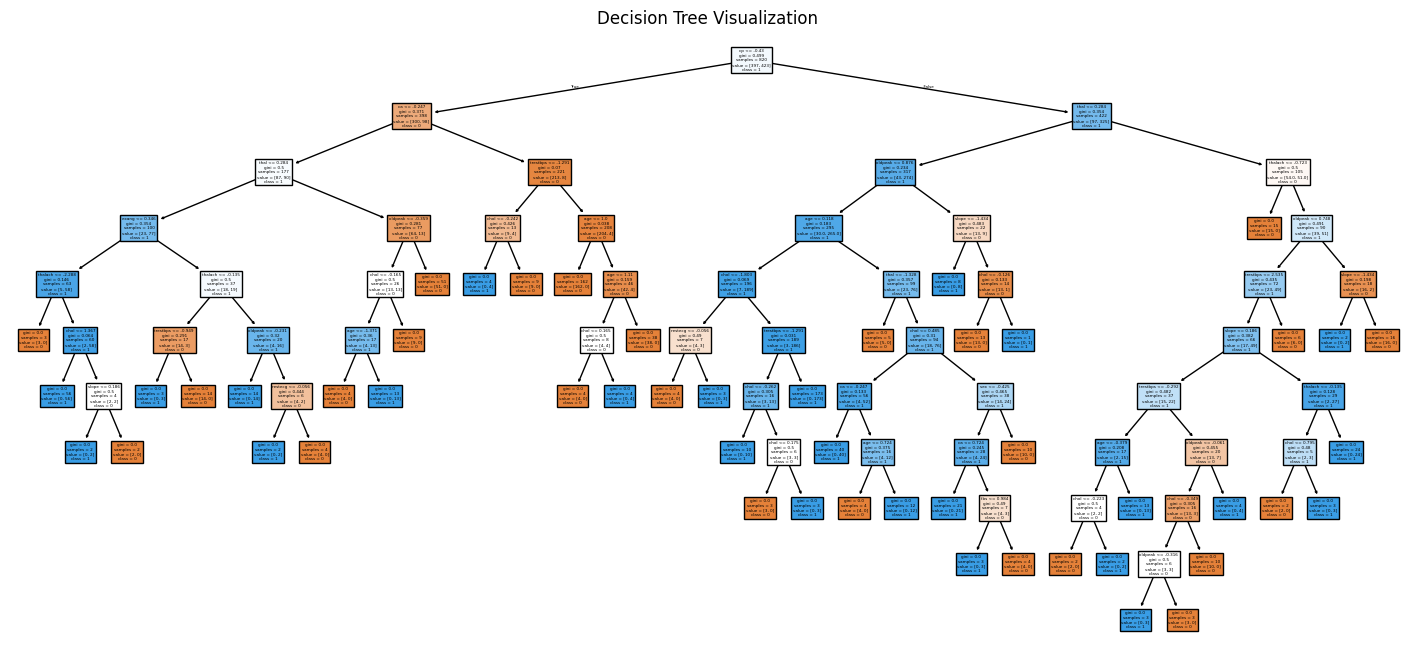

In [9]:
#1. Train a Decision Tree & Visualize It
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Visualize the tree
plt.figure(figsize=(18, 8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=["0", "1"])
plt.title("Decision Tree Visualization")
plt.show()


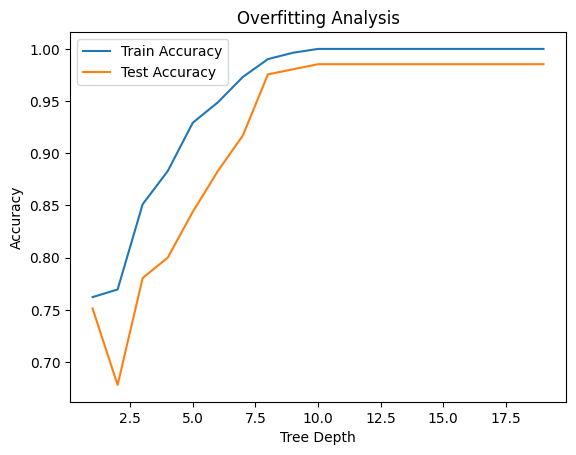

In [10]:
#2. Analyze Overfitting & Control Tree Depth
train_scores = []
test_scores = []
depths = range(1, 20)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# Plot accuracy vs depth
plt.plot(depths, train_scores, label="Train Accuracy")
plt.plot(depths, test_scores, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")
plt.legend()
plt.show()


In [11]:
#3. Train a Random Forest & Compare Accuracy
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


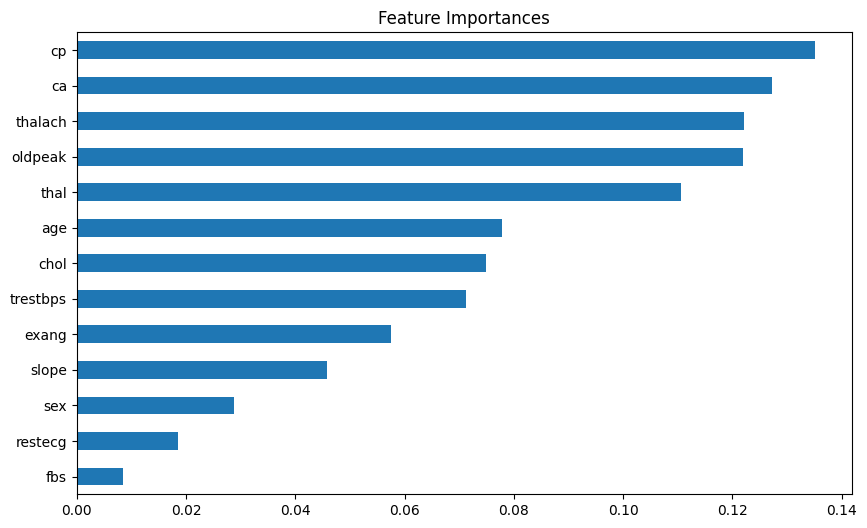

In [12]:
#4. Interpret Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title="Feature Importances")
plt.show()

In [13]:
#5. Evaluate Using Cross-Validation
# 5-fold cross-validation
dt_cv_score = cross_val_score(dt, X_scaled, y, cv=5)
rf_cv_score = cross_val_score(rf, X_scaled, y, cv=5)

print("Decision Tree CV Accuracy:", dt_cv_score.mean())
print("Random Forest CV Accuracy:", rf_cv_score.mean())


Decision Tree CV Accuracy: 1.0
Random Forest CV Accuracy: 0.9970731707317073
